In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Load the NSW Fire History shapefile
fire_history = gpd.read_file('/Users/josephpradil/Desktop/project1_bushfire/fire_npwsfirehistory (1)/NPWSFireHistory.shp')

# Basic info
print("Shape:", fire_history.shape)
print("\nColumns:", fire_history.columns.tolist())
print("\nCRS:", fire_history.crs)
print("\nFirst 5 rows:")
print(fire_history.head())

Shape: (37588, 9)

Columns: ['FireName', 'FireNo', 'Label', 'StartDate', 'EndDate', 'AreaHa', 'PerimeterM', 'VerDate', 'geometry']

CRS: EPSG:4283

First 5 rows:
  FireName  FireNo                    Label  StartDate EndDate      AreaHa  \
0      NaN     NaN  1970-71 Prescribed Burn        NaT     NaT  299.985464   
1      NaN  70/161  1970-71 Prescribed Burn        NaT     NaT  309.025645   
2      NaN     NaN  1970-71 Prescribed Burn 1970-07-01     NaT   13.600002   
3      NaN       0  1971-72 Prescribed Burn 1971-07-01     NaT   58.994371   
4      NaN       0  1971-72 Prescribed Burn 1971-07-01     NaT  383.155154   

     PerimeterM   VerDate                                           geometry  
0   8615.637120  7/5/2026  POLYGON ((152.77796 -31.63806, 152.77822 -31.6...  
1  20657.633993  7/5/2026  POLYGON ((151.50894 -31.98245, 151.50911 -31.9...  
2   1999.487701  7/5/2026  POLYGON ((153.14728 -30.17573, 153.14721 -30.1...  
3   5312.210152  7/5/2026  POLYGON ((152.2127 -32.241

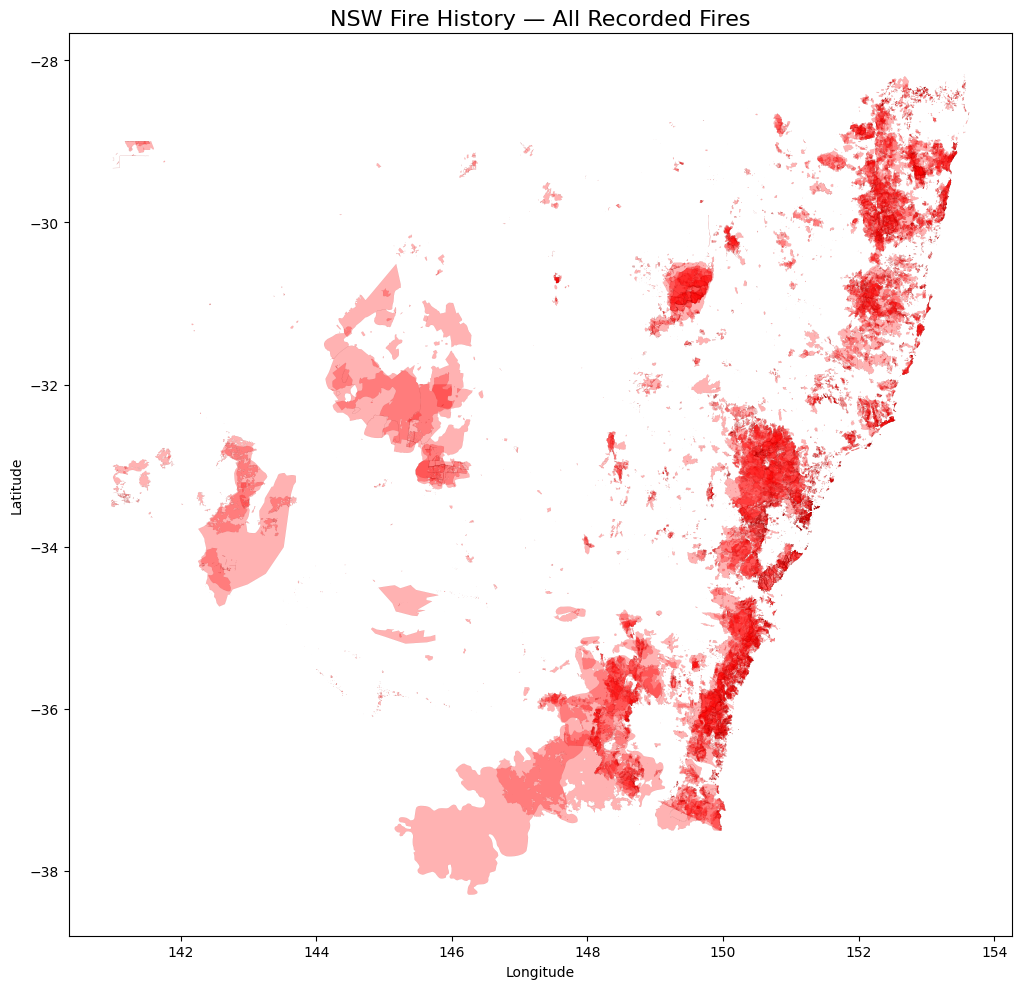

Total fires recorded: 37,588
Total area burned: 34,446,191 hectares


In [2]:
# Plot all fire history
fig, ax = plt.subplots(figsize=(12, 10))

fire_history.plot(ax=ax, 
                  color='red', 
                  alpha=0.3, 
                  edgecolor='darkred',
                  linewidth=0.1)

ax.set_title('NSW Fire History — All Recorded Fires', fontsize=16)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('nsw_fire_history.png', dpi=150)
plt.show()

print(f"Total fires recorded: {len(fire_history):,}")
print(f"Total area burned: {fire_history['AreaHa'].sum():,.0f} hectares")

In [3]:
import folium
import json

# Convert to WGS84 for folium
fire_wgs84 = fire_history.to_crs(epsg=4326)

# Create folium map centered on NSW
m = folium.Map(location=[-32.5, 147.5], zoom_start=6)

# Add fire history as a layer (use recent fires only to keep it fast)
recent_fires = fire_wgs84[fire_wgs84['StartDate'] >= '2000-01-01'].copy()

print(f"Fires since 2000: {len(recent_fires):,}")
print("Adding to map...")

# Add to map
folium.GeoJson(
    recent_fires,
    style_function=lambda x: {
        'fillColor': 'red',
        'color': 'darkred',
        'weight': 0.5,
        'fillOpacity': 0.4
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['Label', 'StartDate', 'AreaHa'],
        aliases=['Fire Name', 'Start Date', 'Area (Ha)']
    )
).add_to(m)

m.save('/Users/josephpradil/Desktop/gis-portfolio/nsw_fire_history.html')
print("Interactive map saved!")

Fires since 2000: 17,630
Adding to map...


TypeError: Object of type Timestamp is not JSON serializable

In [4]:
# Convert dates to strings to fix JSON serialization
recent_fires['StartDate'] = recent_fires['StartDate'].astype(str)
recent_fires['EndDate'] = recent_fires['EndDate'].astype(str)

# Create folium map centered on NSW
m = folium.Map(location=[-32.5, 147.5], zoom_start=6)

# Add to map
folium.GeoJson(
    recent_fires,
    style_function=lambda x: {
        'fillColor': 'red',
        'color': 'darkred',
        'weight': 0.5,
        'fillOpacity': 0.4
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['Label', 'StartDate', 'AreaHa'],
        aliases=['Fire Name', 'Start Date', 'Area (Ha)']
    )
).add_to(m)

m.save('/Users/josephpradil/Desktop/gis-portfolio/nsw_fire_history.html')
print("Interactive map saved!")

Interactive map saved!


In [5]:
# Simplify geometries to reduce file size
recent_fires_simple = recent_fires.copy()
recent_fires_simple['geometry'] = recent_fires_simple.geometry.simplify(0.001)

# Create map
m = folium.Map(location=[-32.5, 147.5], zoom_start=6)

recent_fires_simple['StartDate'] = recent_fires_simple['StartDate'].astype(str)
recent_fires_simple['EndDate'] = recent_fires_simple['EndDate'].astype(str)

folium.GeoJson(
    recent_fires_simple,
    style_function=lambda x: {
        'fillColor': 'red',
        'color': 'darkred',
        'weight': 0.5,
        'fillOpacity': 0.4
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['Label', 'StartDate', 'AreaHa'],
        aliases=['Fire Name', 'Start Date', 'Area (Ha)']
    )
).add_to(m)

m.save('/Users/josephpradil/Desktop/gis-portfolio/nsw_fire_history.html')
print("Simplified map saved!")

Simplified map saved!


In [6]:
# Only keep large fires over 1000 hectares
large_fires = recent_fires[recent_fires['AreaHa'] > 1000].copy()
large_fires['geometry'] = large_fires.geometry.simplify(0.001)
large_fires['StartDate'] = large_fires['StartDate'].astype(str)
large_fires['EndDate'] = large_fires['EndDate'].astype(str)

print(f"Large fires (>1000ha): {len(large_fires):,}")

# Create map
m = folium.Map(location=[-32.5, 147.5], zoom_start=6)

folium.GeoJson(
    large_fires,
    style_function=lambda x: {
        'fillColor': 'red',
        'color': 'darkred',
        'weight': 0.5,
        'fillOpacity': 0.4
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['Label', 'StartDate', 'AreaHa'],
        aliases=['Fire Name', 'Start Date', 'Area (Ha)']
    )
).add_to(m)

m.save('/Users/josephpradil/Desktop/gis-portfolio/nsw_fire_history.html')
print("Map saved!")

Large fires (>1000ha): 1,161
Map saved!
